# Brain Tumor MRI Classification (Part-1)

**NAME      : KODANDA CHALLA**

**STUDENT ID: 25727**

***Multiclass image classification (4-class)***
- **Glioma**: A tumor that starts in the brain’s glial cells.
- **Meningioma**: A tumor that grows in the protective layers around the brain.
- **Notumor**: MRI scans that show no brain tumor.
- **Pituitary**: A tumor found in the pituitary gland near the base of the brain.



<img src="Images/Tumor.jpg" width="250">

## 1. Project Overview

This notebook trains and compares *five pipelines* on the Brain Tumor MRI dataset: *KNN, SVM, Random Forest, Custom CNN, and ResNet-50 transfer learning*. It follows a clear workflow: load data, inspect images, extract features for classical models, train deep models on raw pixels, explain predictions, and compare performance.

## 2. Import Libraries

In [1]:
import os
from PIL import Image
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
Program_start = time.perf_counter()

import warnings
warnings.filterwarnings('ignore')

## 3. Load and Explore Dataset

### Dataset_MRI Folder Structure

```text
Dataset_MRI/
├── Testing/
│   ├── glioma/
│   ├── meningioma/
│   ├── notumor/
│   └── pituitary/
└── Training/
    ├── glioma/
    ├── meningioma/
    ├── notumor/
    └── pituitary/
```

<img src="Images/Folders.jpg" width="600">

In [2]:
DATASET_PATH = "Dataset_MRI"
TRAIN_DIR = os.path.join(DATASET_PATH, 'Training')
TEST_DIR = os.path.join(DATASET_PATH, 'Testing')
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE_CLASSICAL = 128
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

In [3]:
def build_dataframe(data_dir):
    rows = []
    for label in CLASSES:
        class_dir = os.path.join(data_dir, label)
        for fname in os.listdir(class_dir):
            rows.append({'filepath': os.path.join(class_dir, fname), 'label': label})
    return pd.DataFrame(rows)

train_df = build_dataframe(TRAIN_DIR)
test_df = build_dataframe(TEST_DIR)

print('Train:', train_df.shape)
print('Test:', test_df.shape)
display(train_df.sample(5, random_state=SEED))

Train: (5600, 2)
Test: (1600, 2)


,filepath,label
4795,Dataset_MRI\Training\pituitary\Tr-pi_274.jpg,pituitary
4269,Dataset_MRI\Training\pituitary\Tr-pi_1060.jpg,pituitary
2004,Dataset_MRI\Training\meningioma\Tr-me_282.jpg,meningioma
2515,Dataset_MRI\Training\meningioma\Tr-me_742.jpg,meningioma
3014,Dataset_MRI\Training\notumor\Tr-no_1191.jpg,notumor


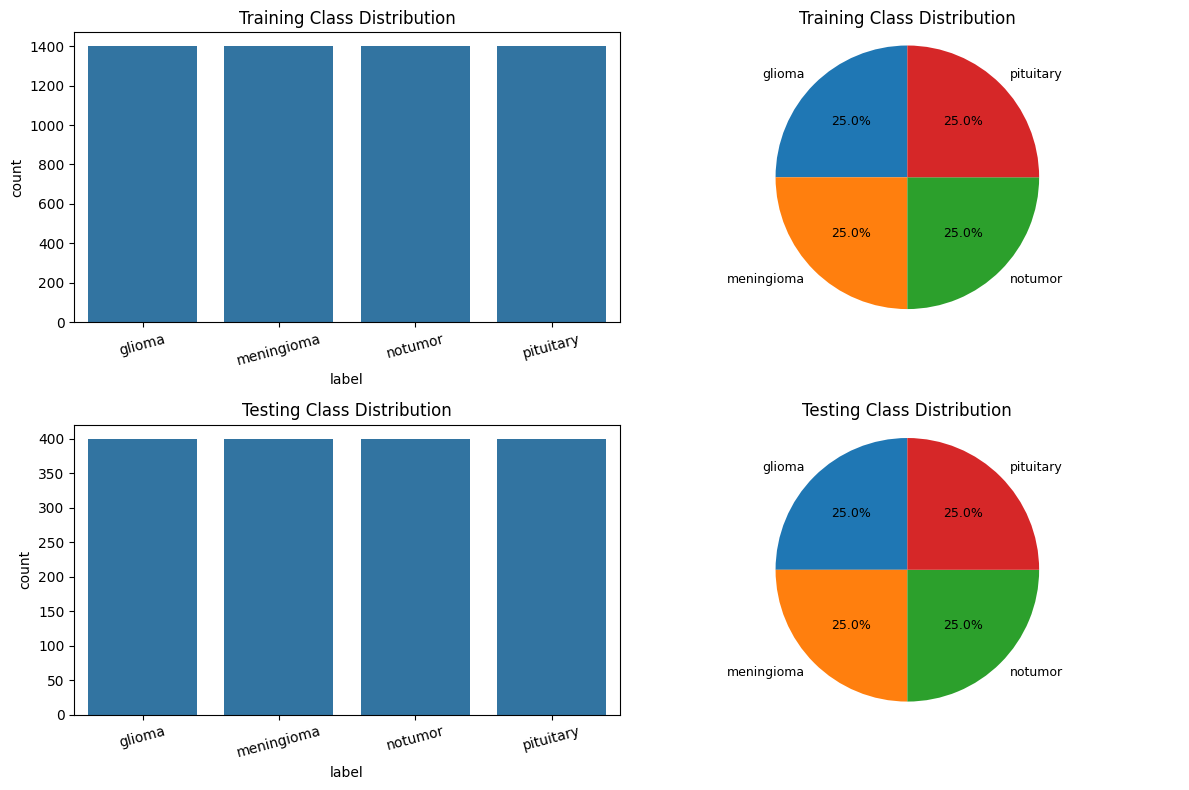

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
sns.countplot(data=train_df, x='label', order=CLASSES, ax=ax)
ax.set_title('Training Class Distribution')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

ax = axes[0, 1]
train_counts = train_df['label'].value_counts().reindex(CLASSES)
ax.pie(train_counts, labels=CLASSES, autopct='%1.1f%%', startangle=90,
       colors=sns.color_palette('tab10', len(CLASSES)), textprops={'fontsize': 9})
ax.set_title('Training Class Distribution')
ax.axis('equal')

ax = axes[1, 0]
sns.countplot(data=test_df, x='label', order=CLASSES, ax=ax)
ax.set_title('Testing Class Distribution')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

ax = axes[1, 1]
test_counts = test_df['label'].value_counts().reindex(CLASSES)
ax.pie(test_counts, labels=CLASSES, autopct='%1.1f%%', startangle=90,
       colors=sns.color_palette('tab10', len(CLASSES)), textprops={'fontsize': 9})
ax.set_title('Testing Class Distribution')
ax.axis('equal')

plt.tight_layout()
plt.show()

***Both the training and testing datasets are well balanced across the four classes: glioma, meningioma, notumor, and pituitary. This balanced distribution supports reliable model development and evaluation by preventing class bias in both training and test splits.***

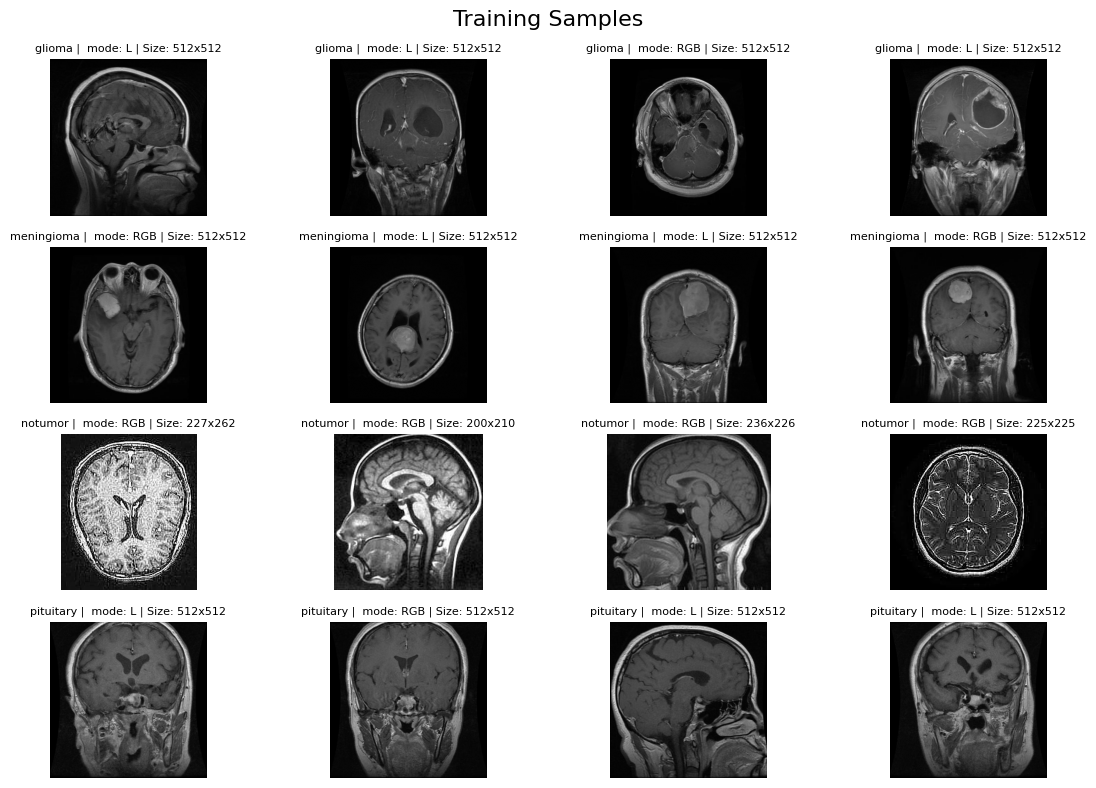

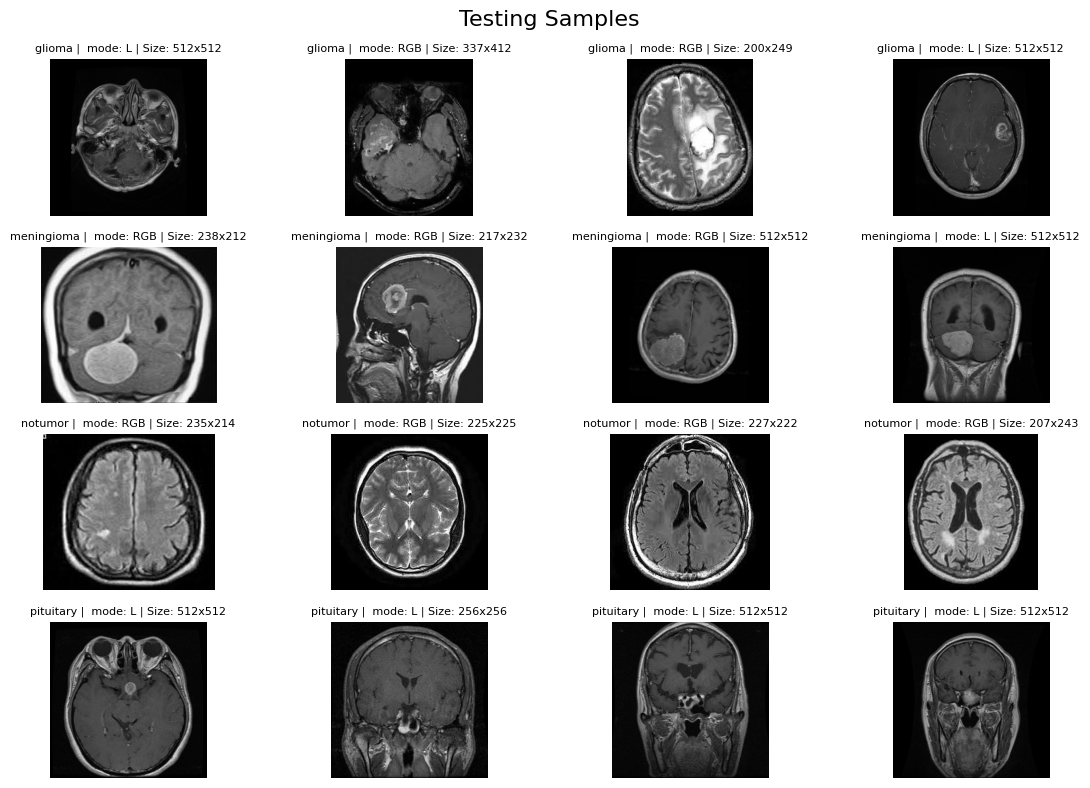

In [5]:
def show_samples(df, classes, n=4, title=None):
    plt.figure(figsize=(12, 8))
    idx = 1
    for label in classes:
        samples = df[df['label'] == label]['filepath'].sample(n, random_state=SEED).values
        for f in samples:
            img_pil = Image.open(f)
            mode = img_pil.mode
            img = np.array(img_pil)
            plt.subplot(len(classes), n, idx)
            plt.imshow(img_pil, cmap='gray' if mode == 'L' else None)
            height, width = img.shape[:2]
            plt.title(f'{label} |  mode: {mode} | Size: {width}x{height}', fontsize=8 )
            plt.axis('off')
            idx += 1
    if title:
        plt.suptitle(title, fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

show_samples(train_df, CLASSES, n=4, title='Training Samples')
show_samples(test_df, CLASSES, n=4, title='Testing Samples')

***The images across training and test datas have different sizes. To ensure consistency across the dataset and enable efficient batch processing in machine learning models, all images are resized to a standard size before feature extraction and model training.***

***The image dataset contains both RGB and grayscale images. This means the preprocessing pipeline must handle both color and monochrome inputs consistently before extracting features.***

## 4. Feature Extraction for Classical Models

This code extracts handcrafted image features from each MRI scan, producing a fixed-length feature vector that classical classifiers like KNN, SVM, and Random Forest can use.

Feature types extracted:
1. HOG features
   - `hog(...)` computes Histogram of Oriented Gradients on the grayscale image.
   - HOG captures edge and shape information by summarizing gradient directions in local patches.
   - The parameters used are:
     - `orientations=9`: nine gradient direction bins.
     - `pixels_per_cell=(8, 8)`: each cell is 8x8 pixels.
     - `cells_per_block=(2, 2)`: blocks normalize groups of 2x2 cells.
     - `block_norm='L2-Hys'`: uses L2-Hys normalization for better invariance.

2. Texture features from GLCM
   - `graycomatrix(...)` builds a gray-level co-occurrence matrix, capturing how often pairs of pixel intensities appear at a given offset.
   - `graycoprops(...)` extracts texture statistics from this matrix.
   - The six texture descriptors are:
     - `contrast`: measures local intensity variation. High values indicate strong edges or texture.
     - `dissimilarity`: another edge-sensitive measure that weights larger intensity differences.
     - `homogeneity`: measures similarity of pixel pairs; high values mean less texture variation.
     - `energy`: indicates textural uniformity or repeated patterns.
     - `correlation`: measures linear intensity dependency across pixel pairs.
     - `ASM` (angular second moment): also known as energy squared, reflecting texture order.

In [6]:
import cv2
from skimage.feature import hog, graycomatrix, graycoprops
from sklearn.preprocessing import LabelEncoder, StandardScaler


def extract_features(image_path, img_size=128):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)# Convert BGR to RGB
    img = cv2.resize(img, (img_size, img_size))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # Convert to grayscale for feature extraction

    hog_features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    texture_features = [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'dissimilarity')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0],
        graycoprops(glcm, 'ASM')[0, 0]
    ]

    return np.hstack([hog_features, texture_features])

X_train_classical = np.array([extract_features(fp, IMG_SIZE_CLASSICAL) for fp in train_df['filepath']])
X_test_classical = np.array([extract_features(fp, IMG_SIZE_CLASSICAL) for fp in test_df['filepath']])

le = LabelEncoder()
y_train_classical = le.fit_transform(train_df['label'])
y_test_classical = le.transform(test_df['label'])

scaler = StandardScaler()
X_train_classical = scaler.fit_transform(X_train_classical)
X_test_classical = scaler.transform(X_test_classical)

print(X_train_classical.shape, X_test_classical.shape)

(5600, 8106) (1600, 8106)


## 5. Feature Reduction (PCA)

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_classical)
X_test_pca = pca.transform(X_test_classical)

print(f"Reduced from {X_train_classical.shape[1]} to {X_train_pca.shape[1]} (variance: {pca.explained_variance_ratio_.sum():.1%})")

Reduced from 8106 to 1622 (variance: 95.0%)


- Each image produces 8100 HOG features from the 128×128 grayscale input.
- Six GLCM texture features are extracted (`contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, `ASM`).
- This gives a total of 8106 handcrafted features per image before dimensionality reduction.
- PCA with `n_components=0.95` reduces the feature space from 8106 features to 1622 features while preserving 95% of the variance.

## 6. Training and Evaluation of Classical Machine Learning Models
- Models evaluated: KNN, SVM, and Random Forest trained on PCA-reduced features (1622 dims).
- Metrics reported: overall accuracy, per-class precision/recall/f1 (from `classification_report`), and confusion matrices for class-wise errors.
- Training time is measured for each model and recorded in the `results` list for comparison.
- Use confusion matrices to identify common misclassifications and `classification_report` to inspect class imbalance effects and per-class performance.

KNN - Time taken: 0.04 seconds

KNN
Accuracy: 0.8425
              precision    recall  f1-score   support

      glioma       0.88      0.74      0.80       400
  meningioma       0.87      0.68      0.77       400
     notumor       0.79      0.99      0.88       400
   pituitary       0.85      0.96      0.90       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.84      1600
weighted avg       0.85      0.84      0.84      1600



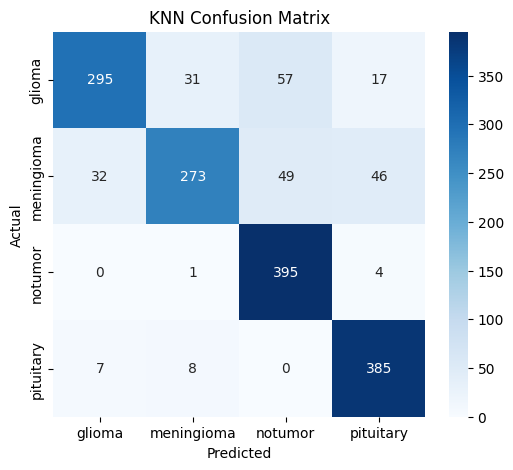

SVM - Time taken: 16.56 seconds

SVM
Accuracy: 0.886875
              precision    recall  f1-score   support

      glioma       0.96      0.67      0.79       400
  meningioma       0.83      0.90      0.87       400
     notumor       0.86      1.00      0.92       400
   pituitary       0.92      0.98      0.95       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.88      1600
weighted avg       0.89      0.89      0.88      1600



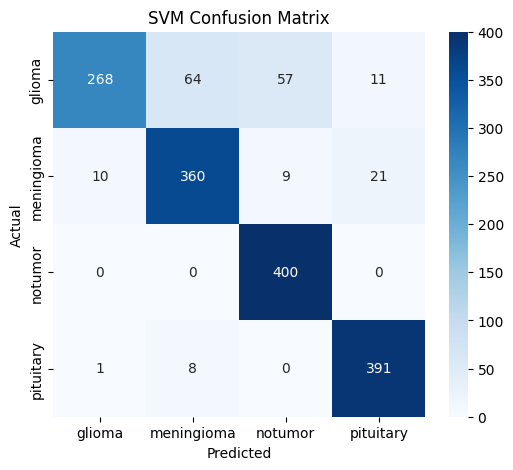

Random Forest - Time taken: 16.49 seconds

Random Forest
Accuracy: 0.84875
              precision    recall  f1-score   support

      glioma       0.85      0.67      0.75       400
  meningioma       0.76      0.80      0.78       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.90      0.94      0.92       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.84      1600
weighted avg       0.85      0.85      0.84      1600



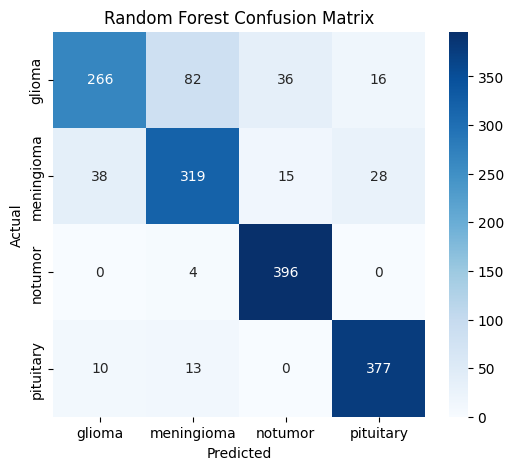

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import time

results = []

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    train_time = end - start
    print(f'{name} - Time taken: {train_time:.2f} seconds')

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f'\n{name}')
    print('Accuracy:', acc)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    results.append({'Model': name, 'Accuracy': acc, 'Train Time (s)': train_time})

knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(random_state=SEED)
rf = RandomForestClassifier(random_state=SEED)

evaluate_model('KNN', knn, X_train_pca, y_train_classical, X_test_pca, y_test_classical)
evaluate_model('SVM', svm, X_train_pca, y_train_classical, X_test_pca, y_test_classical)
evaluate_model('Random Forest', rf, X_train_pca, y_train_classical, X_test_pca, y_test_classical)

## 7. Hyperparameter Tuning Pipeline

This section performs systematic hyperparameter tuning for KNN, SVM, and Random Forest using GridSearchCV on the PCA-reduced features. Each model pipeline is separated into its own cell, and learning curves are plotted to show training and validation behavior.

- Uses `GridSearchCV` (5-fold CV, `n_jobs=-1`) to search parameter grids for each estimator and optimize `accuracy`.
- Grid search returns the best estimator and cross-validation score (`best_estimator_`, `best_score_`).
- After tuning, the best models are refit on the full training set and evaluated on the hold-out test set to measure generalization performance.
- Compare tuned vs. default models using test accuracy and confusion matrices to quantify improvement.

In [9]:
from sklearn.model_selection import GridSearchCV, learning_curve


def tune_model(model, param_grid, X_train, y_train, cv=5, scoring='accuracy'):
    start = time.time()
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)
    end = time.time()
    print(f'{model.__class__.__name__} tuning time: {end - start:.2f} seconds')

    return grid_search


### 7.1 KNN Hyperparameter Tuning

Tuning KNN on PCA-reduced features and plotting the learning curve for the best estimator.

In [ ]:
knn_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_search = tune_model(KNeighborsClassifier(), knn_grid, X_train_pca, y_train_classical)
print('Best KNN params:', knn_search.best_params_)
print('Best KNN CV score:', knn_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
KNeighborsClassifier tuning time: 96.57 seconds
Best KNN params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV score: 0.9392857142857143


In [11]:
svm_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

svm_search = tune_model(SVC(random_state=SEED), svm_grid, X_train_pca, y_train_classical)
print('Best SVM params:', svm_search.best_params_)
print('Best SVM CV score:', svm_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
SVC tuning time: 870.43 seconds
Best SVM params: {'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}
Best SVM CV score: 0.9192857142857143


### 7.3 Random Forest Hyperparameter Tuning

Tuning Random Forest on PCA-reduced features and plotting the learning curve for the best estimator.

In [12]:
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_search = tune_model(RandomForestClassifier(random_state=SEED), rf_grid, X_train_pca, y_train_classical)
print('Best Random Forest params:', rf_search.best_params_)
print('Best Random Forest CV score:', rf_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
RandomForestClassifier tuning time: 146.69 seconds
Best Random Forest params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Random Forest CV score: 0.8703571428571429


### 7.4 Evaluation of Tuned Models

Evaluate the tuned models on the test set and compare results across KNN, SVM, and Random Forest.


KNN (Tuned)
Accuracy: 0.900625
              precision    recall  f1-score   support

      glioma       0.91      0.78      0.84       400
  meningioma       0.93      0.86      0.89       400
     notumor       0.86      1.00      0.92       400
   pituitary       0.92      0.95      0.94       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



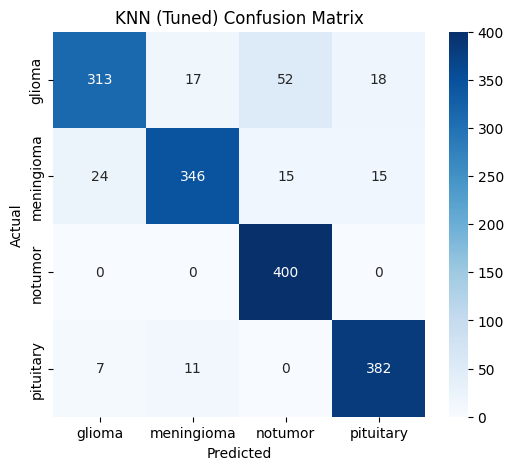


SVM (Tuned)
Accuracy: 0.885625
              precision    recall  f1-score   support

      glioma       0.94      0.69      0.79       400
  meningioma       0.79      0.89      0.84       400
     notumor       0.88      1.00      0.94       400
   pituitary       0.96      0.97      0.96       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.88      1600
weighted avg       0.89      0.89      0.88      1600



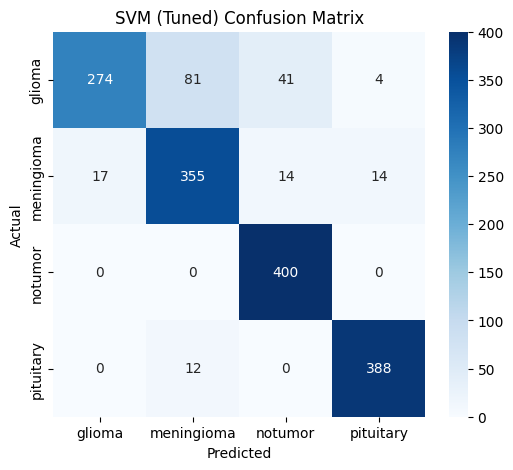


Random Forest (Tuned)
Accuracy: 0.83375
              precision    recall  f1-score   support

      glioma       0.81      0.65      0.72       400
  meningioma       0.77      0.77      0.77       400
     notumor       0.88      0.99      0.93       400
   pituitary       0.87      0.93      0.90       400

    accuracy                           0.83      1600
   macro avg       0.83      0.83      0.83      1600
weighted avg       0.83      0.83      0.83      1600



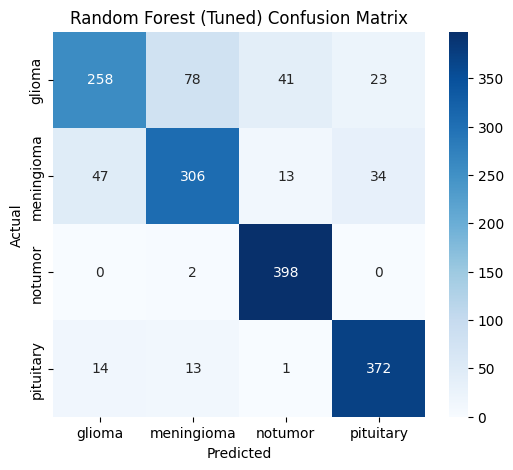

In [13]:
from sklearn.metrics import classification_report, accuracy_score

best_models = {
    'KNN (Tuned)': knn_search.best_estimator_,
    'SVM (Tuned)': svm_search.best_estimator_,
    'Random Forest (Tuned)': rf_search.best_estimator_
}

for name, model in best_models.items():
    model.fit(X_train_pca, y_train_classical)
    preds = model.predict(X_test_pca)
    print(f'\n{name}')
    print('Accuracy:', accuracy_score(y_test_classical, preds))
    print(classification_report(y_test_classical, preds, target_names=le.classes_))
    cm = confusion_matrix(y_test_classical, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()        

## 8. Learning Curves

Learning curves plot training and validation scores against the number of training samples. They help diagnose whether a model suffers from high bias (underfitting) or high variance (overfitting).

Generating learning curves for best models...



Processing Models:   0%|          | 0/3 [00:00<?, ?it/s]

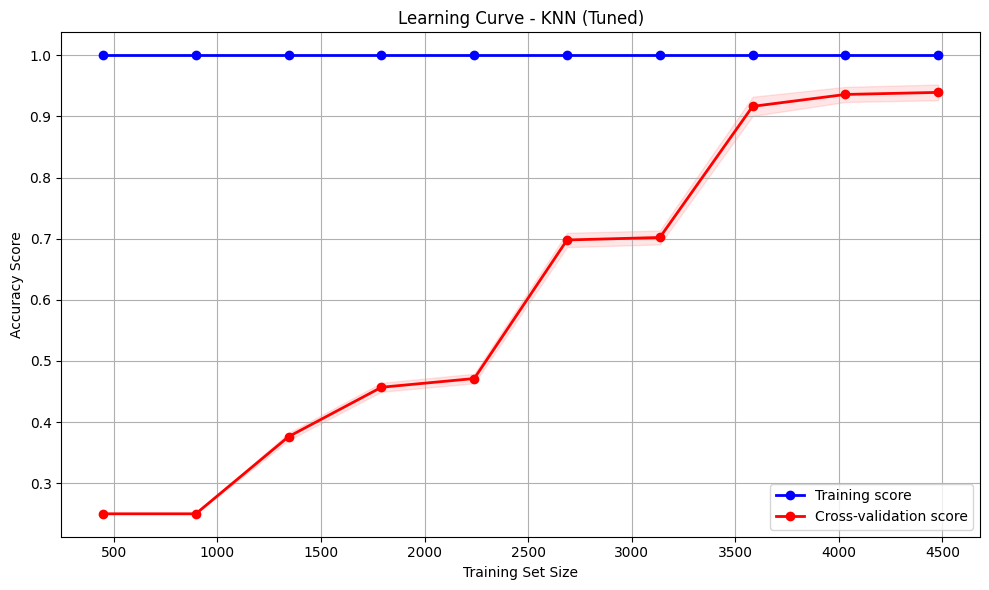

Processing Models:  33%|███▎      | 1/3 [00:12<00:24, 12.15s/it]

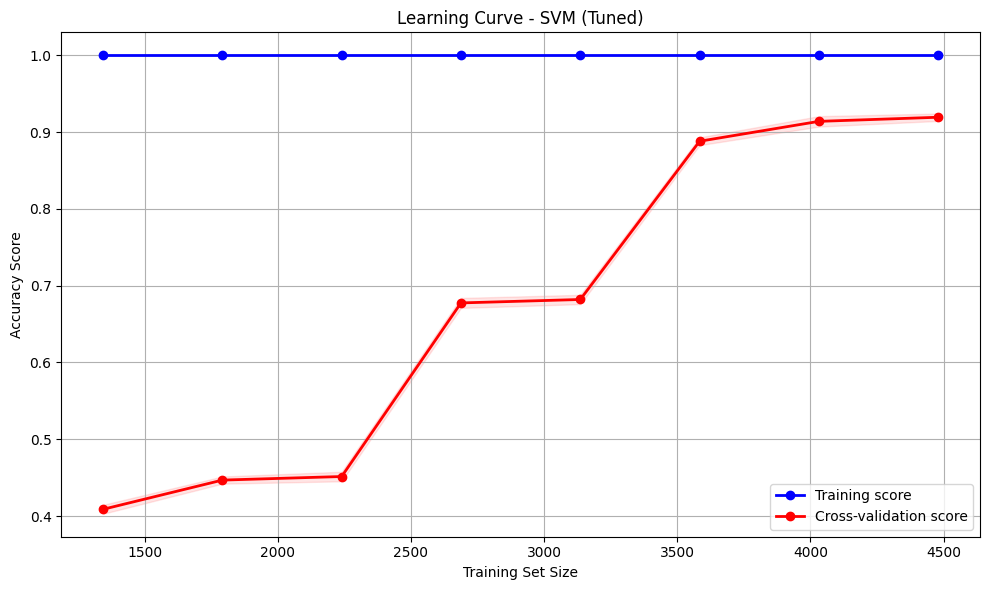

Processing Models:  67%|██████▋   | 2/3 [02:47<01:36, 96.36s/it]

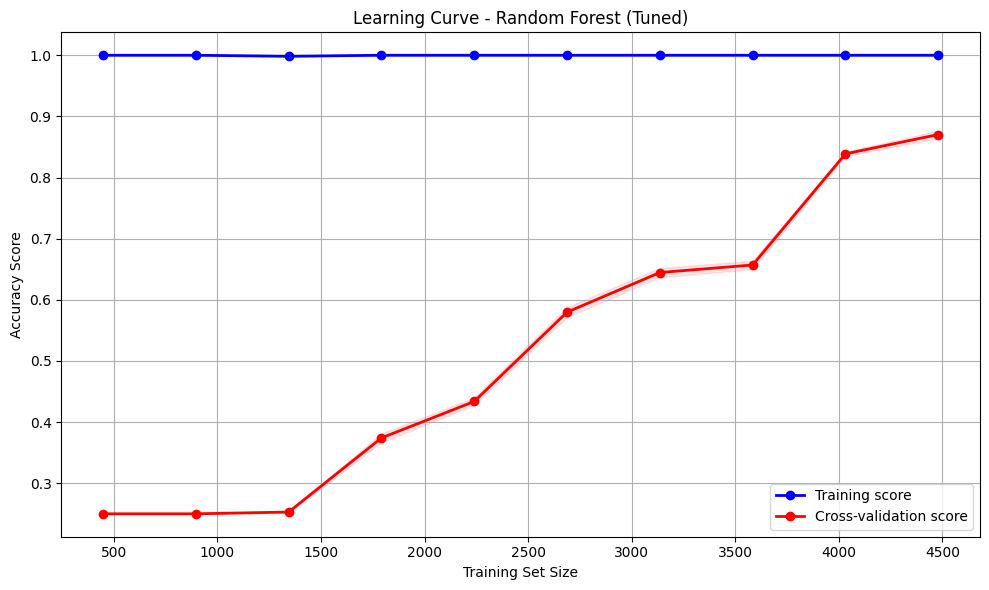

Processing Models: 100%|██████████| 3/3 [03:31<00:00, 70.36s/it]


In [14]:
from sklearn.model_selection import learning_curve
from tqdm import tqdm

# Function to plot learning curves
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.grid()
    
    # Plot training scores
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score', linewidth=2)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    
    # Plot validation scores
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Cross-validation score', linewidth=2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

# Plot learning curves for best models
print('Generating learning curves for best models...\n')

for name, model in tqdm(best_models.items(), desc='Processing Models'):
    plot_learning_curve(model, f'Learning Curve - {name}', X_train_pca, y_train_classical, cv=5)

In [15]:
Program_end = time.perf_counter()
print(f'\nTotal execution time: {Program_end - Program_start:.2f} seconds')


Total execution time: 1570.46 seconds
